In [15]:
# Standard Library
import os
import re
import warnings
from collections import Counter, defaultdict

# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier

# Imbalanced Learning
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

# Gradient Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Explainability
import shap
import lime
import lime.lime_tabular

# Config
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
warnings.filterwarnings('ignore', category=UserWarning)
df = pd.read_csv('data/dataset.csv')
df = df[df['KPSP Detection Results'] != 'f'].copy()


### Parse Age and Encode Skills

In [16]:
def parse_age_to_months(age_str):
    if pd.isna(age_str): return np.nan
    age_str = str(age_str).upper()
    months = 0
    year_match = re.search(r'(\d+)\s*(?:THN|TAHUN|TH)', age_str)
    if year_match: months += int(year_match.group(1)) * 12
    month_match = re.search(r'(\d+)\s*(?:BLN|BULAN|BL)', age_str)
    if month_match: months += int(month_match.group(1))
    return months if months != 0 else np.nan

df['Age_Months'] = df['Age'].apply(parse_age_to_months)

def encode_dev(value):
    if pd.isna(value) or str(value).upper() in ['NAN', 'NONE']:
        return np.nan
    if value in ['\u221a', '√']:
        return 1
    if str(value).upper() == 'X':
        return 0
    try:
        return int(value)
    except:
        return np.nan

dev_cols = [
    'Gross Motor Skills',
    'Fine Motor Skills',
    'Speaking/Language',
    'Socialization'
]

for col in dev_cols:
    df[col] = df[col].apply(encode_dev)


### Feature Engineering

In [17]:
df['TotalScore'] = df[dev_cols].sum(axis=1)
df['MeanScore'] = df[dev_cols].mean(axis=1)
df['DelayCount'] = (df[dev_cols] == 0).sum(axis=1)
df['ScorePerMonth'] = df['TotalScore'] / (df['Age_Months'] + 1)


### Vectorized Labels

In [18]:
conds_1 = [
    df['KPSP Detection Results'].str.contains('DS', na=False),
    df['KPSP Detection Results'].str.contains('DM', na=False),
    df['KPSP Detection Results'].str.contains('DP', na=False)
]
choices_1 = [0, 1, 1]
df['Target_Scenario_1'] = np.select(conds_1, choices_1, default=np.nan)

choices_2 = [0, 1, 2]
df['Target_Scenario_2'] = np.select(conds_1, choices_2, default=np.nan)


In [19]:
feature_cols = ['Age_Months'] + dev_cols + ['TotalScore', 'MeanScore', 'DelayCount', 'ScorePerMonth']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), feature_cols)
    ]
)

feature_names = feature_cols


### Custom OOSI Function

In [20]:
def oosi(X_arr, y_arr, columns=None):
    X = pd.DataFrame(X_arr, columns=columns) if not isinstance(X_arr, pd.DataFrame) else X_arr.copy()
    y = pd.Series(y_arr).reset_index(drop=True) if not isinstance(y_arr, pd.Series) else y_arr.copy().reset_index(drop=True)
    
    class_counts = y.value_counts()
    maj_class = class_counts.idxmax()
    max_count = class_counts.max()
    
    Xres, yres = X.copy(), y.copy()
    
    for mino_class in class_counts.index:
        if mino_class == maj_class:
            continue
            
        Xmin = X[y == mino_class]
        nToGen = max_count - len(Xmin)
        
        if nToGen <= 0:
            continue
            
        mean = Xmin.mean()
        std = Xmin.std().replace(0, 0.01)
        
        synthetic = []
        for _ in range(nToGen):
            sample = mean + np.random.normal(0, 1, size=len(mean)) * std
            synthetic.append(sample)
            
        if synthetic:
            Xsyn = pd.DataFrame(synthetic, columns=X.columns)
            ysyn = pd.Series([mino_class] * nToGen)
            Xres = pd.concat([Xres, Xsyn], ignore_index=True)
            yres = pd.concat([yres, ysyn], ignore_index=True)
            
    return Xres, yres

### Models & Stratified CV Evaluation

In [21]:
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_cv(X, y, oversampler_name, dataset_name):
    print(f"\n- Evaluating CV: {dataset_name}")

    metrics  = defaultdict(lambda: defaultdict(list))
    oof_true = defaultdict(list)
    oof_pred = defaultdict(list)

    classes   = np.unique(y)
    n_classes = len(classes)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        X_train_pre = preprocessor.fit_transform(X_train)
        X_test_pre  = preprocessor.transform(X_test)

        X_train_df = pd.DataFrame(X_train_pre, columns=feature_names)
        X_test_df  = pd.DataFrame(X_test_pre,  columns=feature_names)

        if oversampler_name == 'OOSI':
            X_res, y_res = oosi(X_train_df, y_train, columns=feature_names)
        elif oversampler_name == 'SMOTE-ENN':
            n_class_2   = (y_train == 2).sum()
            k_neighbors = max(1, n_class_2 - 1) if n_class_2 > 1 else 1
            smote_enn   = SMOTEENN(smote=SMOTE(k_neighbors=k_neighbors, random_state=42), random_state=42)
            try:
                X_res, y_res = smote_enn.fit_resample(X_train_df, y_train)
            except Exception:
                X_res, y_res = X_train_df, y_train
        else:
            X_res, y_res = X_train_df, y_train

        y_test_bin = label_binarize(y_test, classes=classes)

        for name, model in models.items():
            clf    = clone(model)
            clf.fit(X_res, y_res)
            y_pred = clf.predict(X_test_df)
            y_prob = clf.predict_proba(X_test_df)

            acc         = accuracy_score(y_test, y_pred)
            f1_macro    = f1_score(y_test, y_pred, average='macro',    zero_division=0)
            f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

            if n_classes == 2:
                pr_auc = average_precision_score(y_test_bin.ravel(), y_prob[:, 1])
            else:
                pr_auc = average_precision_score(y_test_bin, y_prob, average='macro')

            metrics[name]['acc'].append(acc)
            metrics[name]['f1_macro'].append(f1_macro)
            metrics[name]['f1_weighted'].append(f1_weighted)
            metrics[name]['pr_auc'].append(pr_auc)

            oof_true[name].extend(y_test.tolist())
            oof_pred[name].extend(y_pred.tolist())

    for name in models.keys():
        print(f"\n--- {name} (5-Fold CV Average) ---")
        print(f"Accuracy : {np.mean(metrics[name]['acc']):.4f} +/- {np.std(metrics[name]['acc']):.4f}")
        print(f"F1 Macro : {np.mean(metrics[name]['f1_macro']):.4f} +/- {np.std(metrics[name]['f1_macro']):.4f}")
        print(f"F1 Avg   : {np.mean(metrics[name]['f1_weighted']):.4f} +/- {np.std(metrics[name]['f1_weighted']):.4f}")
        print(f"PR AUC   : {np.mean(metrics[name]['pr_auc']):.4f} +/- {np.std(metrics[name]['pr_auc']):.4f}")

    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt

    if n_classes == 2:
        label_map = {0: 'Appropriate', 1: 'Deviation/Doubtful'}
    else:
        label_map = {0: 'DS (Appropriate)', 1: 'DM (Doubtful)', 2: 'DP (Deviation)'}
    display_labels = [label_map[c] for c in classes]

    n_models = len(models)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    fig.suptitle(f"5-Fold CV Confusion Matrices -- {dataset_name}", fontsize=13, fontweight='bold')

    for ax, name in zip(axes, models.keys()):
        cm   = confusion_matrix(oof_true[name], oof_pred[name], labels=list(classes))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
        disp.plot(cmap='Blues', ax=ax, colorbar=False)
        ax.set_title(name)

    plt.tight_layout()
    plt.show()


### Execution: Scenario 1


- Evaluating CV: Scenario 1 - Baseline

--- RandomForest (5-Fold CV Average) ---
Accuracy : 0.9935 +/- 0.0129
F1 Macro : 0.9870 +/- 0.0260
F1 Avg   : 0.9938 +/- 0.0123
PR AUC   : 0.9525 +/- 0.0950

--- XGBoost (5-Fold CV Average) ---
Accuracy : 0.9935 +/- 0.0129
F1 Macro : 0.9870 +/- 0.0260
F1 Avg   : 0.9938 +/- 0.0123
PR AUC   : 0.9600 +/- 0.0800

--- LightGBM (5-Fold CV Average) ---
Accuracy : 0.8363 +/- 0.0225
F1 Macro : 0.4554 +/- 0.0067
F1 Avg   : 0.7858 +/- 0.0166
PR AUC   : 0.2938 +/- 0.1407


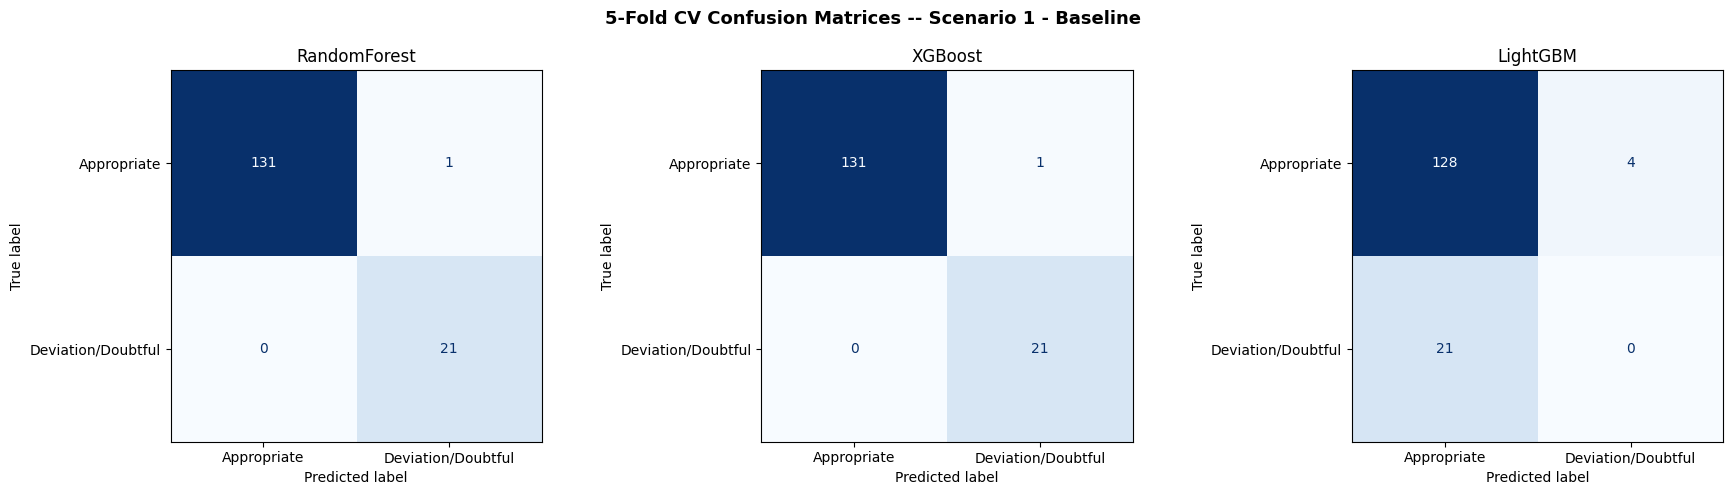


- Evaluating CV: Scenario 1 - OOSI

--- RandomForest (5-Fold CV Average) ---
Accuracy : 0.9935 +/- 0.0129
F1 Macro : 0.9870 +/- 0.0260
F1 Avg   : 0.9938 +/- 0.0123
PR AUC   : 0.9600 +/- 0.0800

--- XGBoost (5-Fold CV Average) ---
Accuracy : 0.9935 +/- 0.0129
F1 Macro : 0.9870 +/- 0.0260
F1 Avg   : 0.9938 +/- 0.0123
PR AUC   : 0.9600 +/- 0.0800

--- LightGBM (5-Fold CV Average) ---
Accuracy : 0.9742 +/- 0.0241
F1 Macro : 0.9422 +/- 0.0540
F1 Avg   : 0.9727 +/- 0.0264
PR AUC   : 0.9600 +/- 0.0800


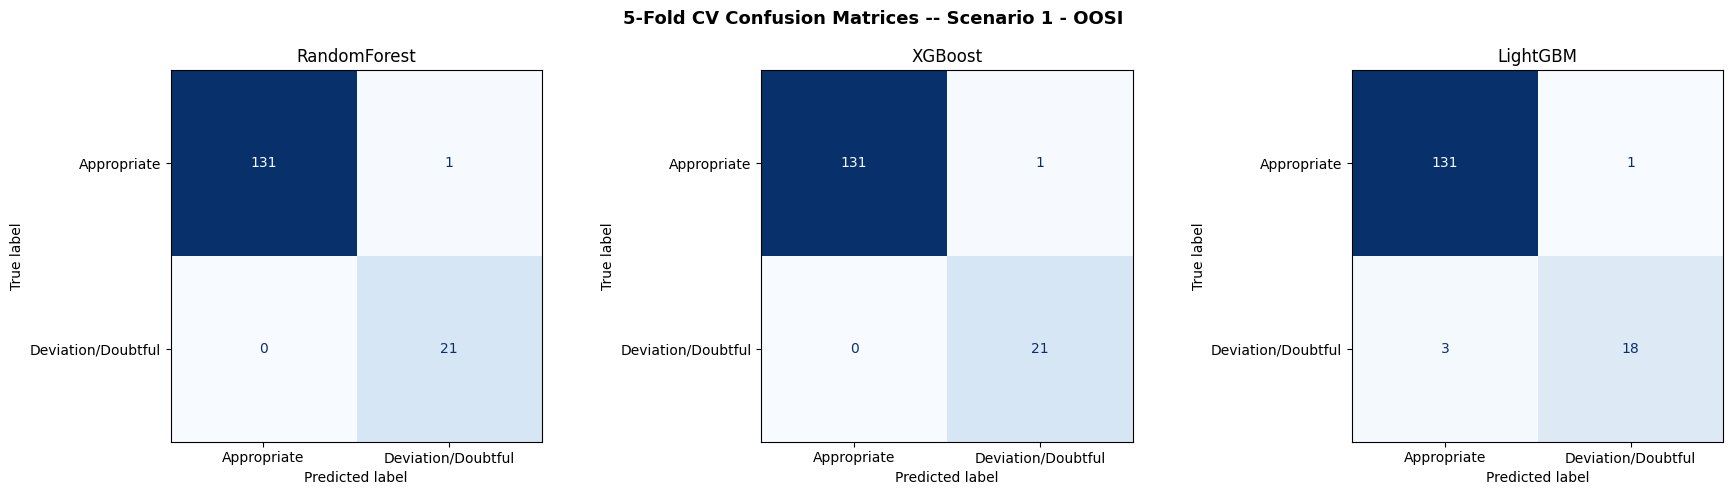


- Evaluating CV: Scenario 1 - SMOTE-ENN

--- RandomForest (5-Fold CV Average) ---
Accuracy : 0.9935 +/- 0.0129
F1 Macro : 0.9870 +/- 0.0260
F1 Avg   : 0.9938 +/- 0.0123
PR AUC   : 0.9600 +/- 0.0800

--- XGBoost (5-Fold CV Average) ---
Accuracy : 0.9935 +/- 0.0129
F1 Macro : 0.9870 +/- 0.0260
F1 Avg   : 0.9938 +/- 0.0123
PR AUC   : 0.9600 +/- 0.0800

--- LightGBM (5-Fold CV Average) ---
Accuracy : 0.9935 +/- 0.0129
F1 Macro : 0.9870 +/- 0.0260
F1 Avg   : 0.9938 +/- 0.0123
PR AUC   : 0.9600 +/- 0.0800


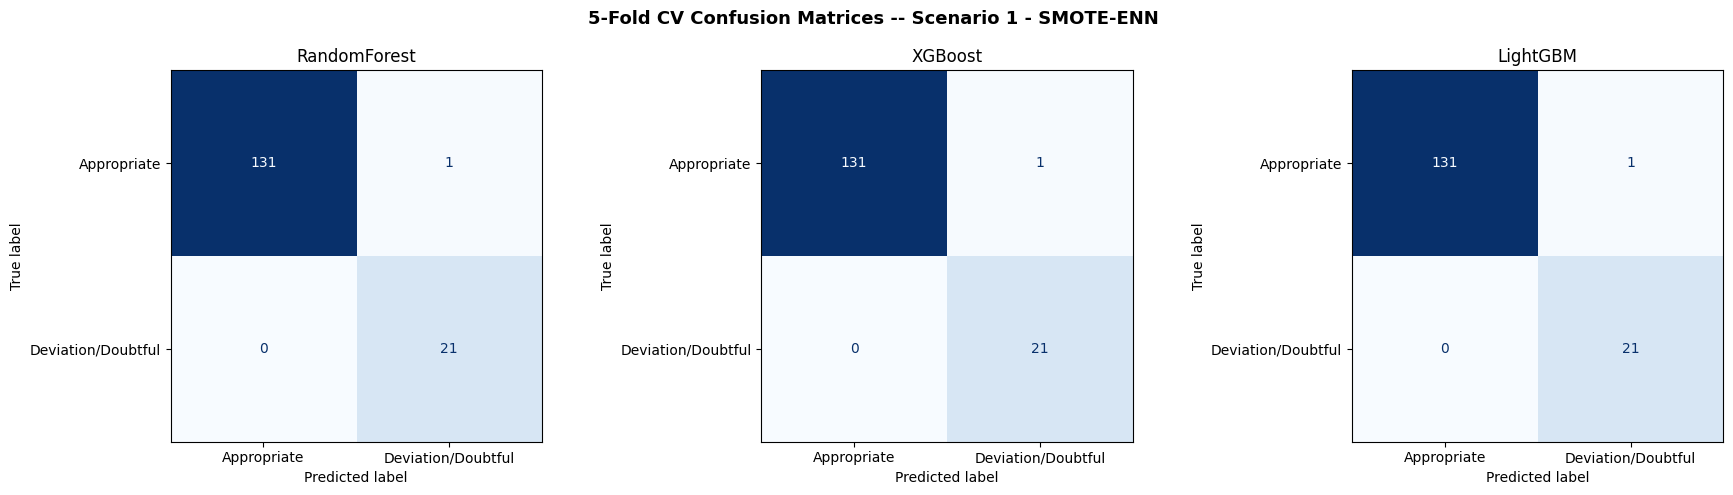

In [22]:
df_s1 = df.dropna(subset=['Target_Scenario_1']).copy()
X1 = df_s1[feature_cols]
y1 = df_s1['Target_Scenario_1'].astype(int)

evaluate_cv(X1, y1, 'Baseline', 'Scenario 1 - Baseline')
evaluate_cv(X1, y1, 'OOSI', 'Scenario 1 - OOSI')
evaluate_cv(X1, y1, 'SMOTE-ENN', 'Scenario 1 - SMOTE-ENN')



--- Scenario 1: SHAP Force Plot ---


Patient 0 | Actual Class: 1


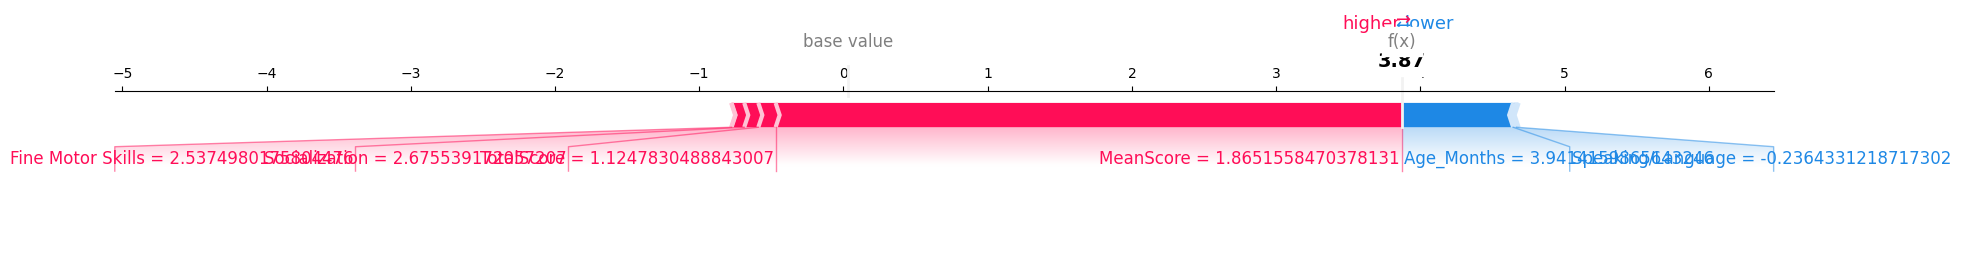

In [23]:
print("\n--- Scenario 1: SHAP Force Plot ---")

X1_pre_full = preprocessor.fit_transform(X1)
X1_df_full  = pd.DataFrame(X1_pre_full, columns=feature_names)
X1_res_full, y1_res_full = oosi(X1_df_full, y1, columns=feature_names)

xgb_explainer_s1 = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_explainer_s1.fit(X1_res_full, y1_res_full)

shap.initjs()
explainer_s1   = shap.TreeExplainer(xgb_explainer_s1)
shap_values_s1 = explainer_s1.shap_values(X1_df_full)

patient_idx_s1 = 0
print(f"Patient {patient_idx_s1} | Actual Class: {y1.iloc[patient_idx_s1]}")

try:
    if isinstance(shap_values_s1, list):
        sv = shap_values_s1[1][patient_idx_s1, :]
        ev = explainer_s1.expected_value[1]
    elif len(np.shape(shap_values_s1)) == 3:
        sv = shap_values_s1[patient_idx_s1, :, 1]
        ev = explainer_s1.expected_value[1]
    else:
        sv = shap_values_s1[patient_idx_s1, :]
        ev = explainer_s1.expected_value
    shap.force_plot(ev, sv, X1_df_full.iloc[patient_idx_s1, :], matplotlib=True, show=False)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not plot Force Plot: {e}")


### Execution: Scenario 2


[WARNING] Fallback: Least populated class has 2 members.
Using regular KFold(n_splits=5) instead of StratifiedKFold to prevent crash!


- Evaluating CV: Scenario 2 - Baseline

--- RandomForest (5-Fold CV Average) ---
Accuracy : 0.9613 +/- 0.0376
F1 Macro : 0.7506 +/- 0.2038
F1 Avg   : 0.9641 +/- 0.0306
PR AUC   : 0.6704 +/- 0.0646

--- XGBoost (5-Fold CV Average) ---
Accuracy : 0.9484 +/- 0.0483
F1 Macro : 0.7170 +/- 0.2327
F1 Avg   : 0.9422 +/- 0.0520
PR AUC   : 0.6686 +/- 0.0146

--- LightGBM (5-Fold CV Average) ---
Accuracy : 0.8370 +/- 0.0395
F1 Macro : 0.4276 +/- 0.1207
F1 Avg   : 0.7931 +/- 0.0661
PR AUC   : 0.4694 +/- 0.0538


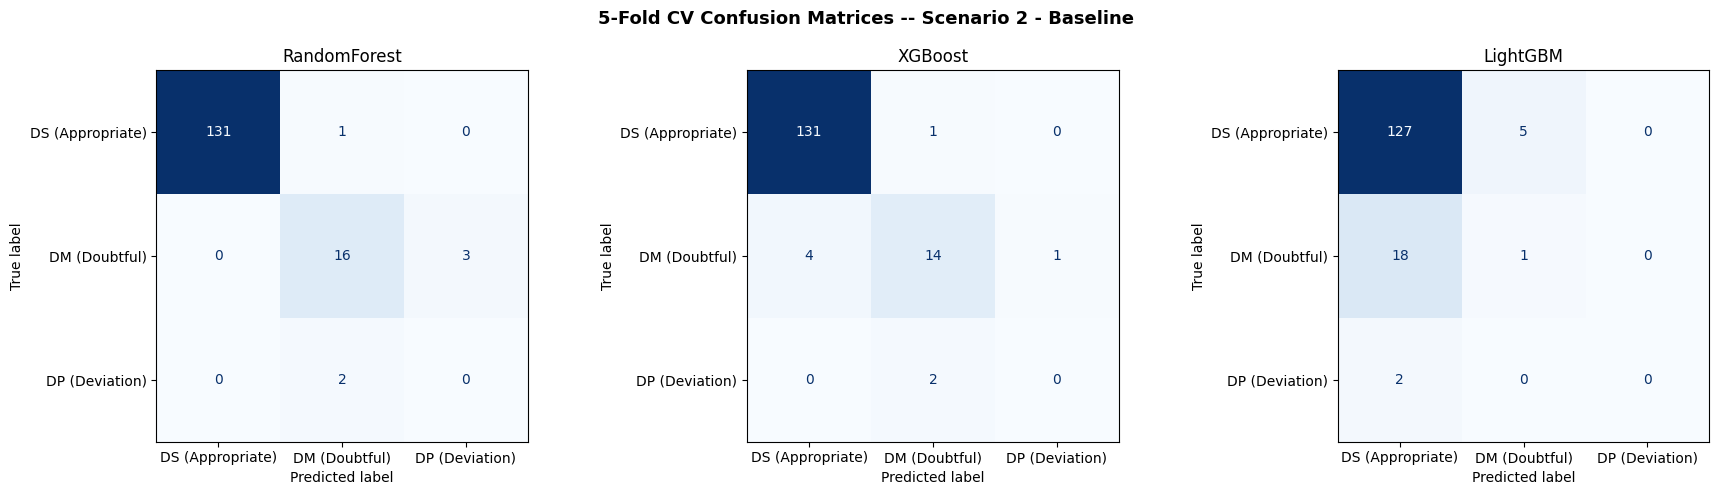


- Evaluating CV: Scenario 2 - OOSI

--- RandomForest (5-Fold CV Average) ---
Accuracy : 0.9742 +/- 0.0241
F1 Macro : 0.7636 +/- 0.1941
F1 Avg   : 0.9729 +/- 0.0282
PR AUC   : 0.6670 +/- 0.0697

--- XGBoost (5-Fold CV Average) ---
Accuracy : 0.9548 +/- 0.0387
F1 Macro : 0.7267 +/- 0.2249
F1 Avg   : 0.9508 +/- 0.0406
PR AUC   : 0.6134 +/- 0.0658

--- LightGBM (5-Fold CV Average) ---
Accuracy : 0.9677 +/- 0.0289
F1 Macro : 0.7424 +/- 0.2154
F1 Avg   : 0.9659 +/- 0.0354
PR AUC   : 0.6542 +/- 0.0403


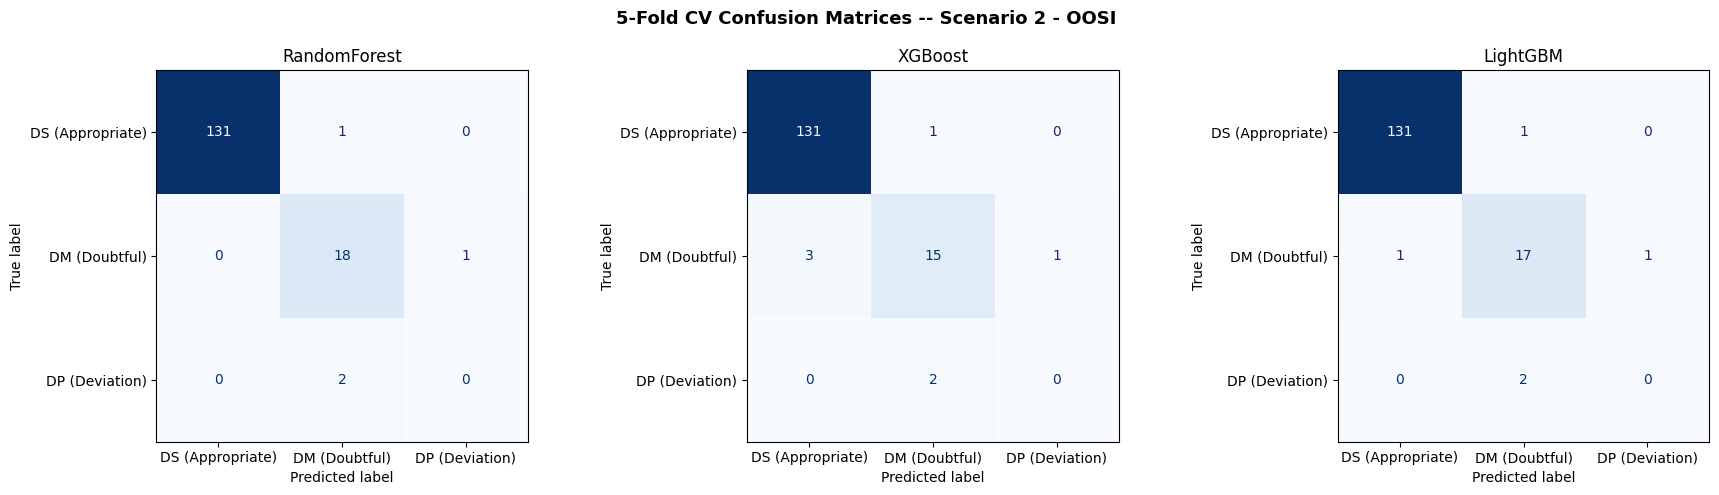


- Evaluating CV: Scenario 2 - SMOTE-ENN

--- RandomForest (5-Fold CV Average) ---
Accuracy : 0.9613 +/- 0.0376
F1 Macro : 0.7506 +/- 0.2038
F1 Avg   : 0.9641 +/- 0.0306
PR AUC   : 0.6704 +/- 0.0646

--- XGBoost (5-Fold CV Average) ---
Accuracy : 0.9548 +/- 0.0387
F1 Macro : 0.7294 +/- 0.2230
F1 Avg   : 0.9570 +/- 0.0356
PR AUC   : 0.6686 +/- 0.0146

--- LightGBM (5-Fold CV Average) ---
Accuracy : 0.9161 +/- 0.0752
F1 Macro : 0.6367 +/- 0.3128
F1 Avg   : 0.9114 +/- 0.0886
PR AUC   : 0.5931 +/- 0.0971


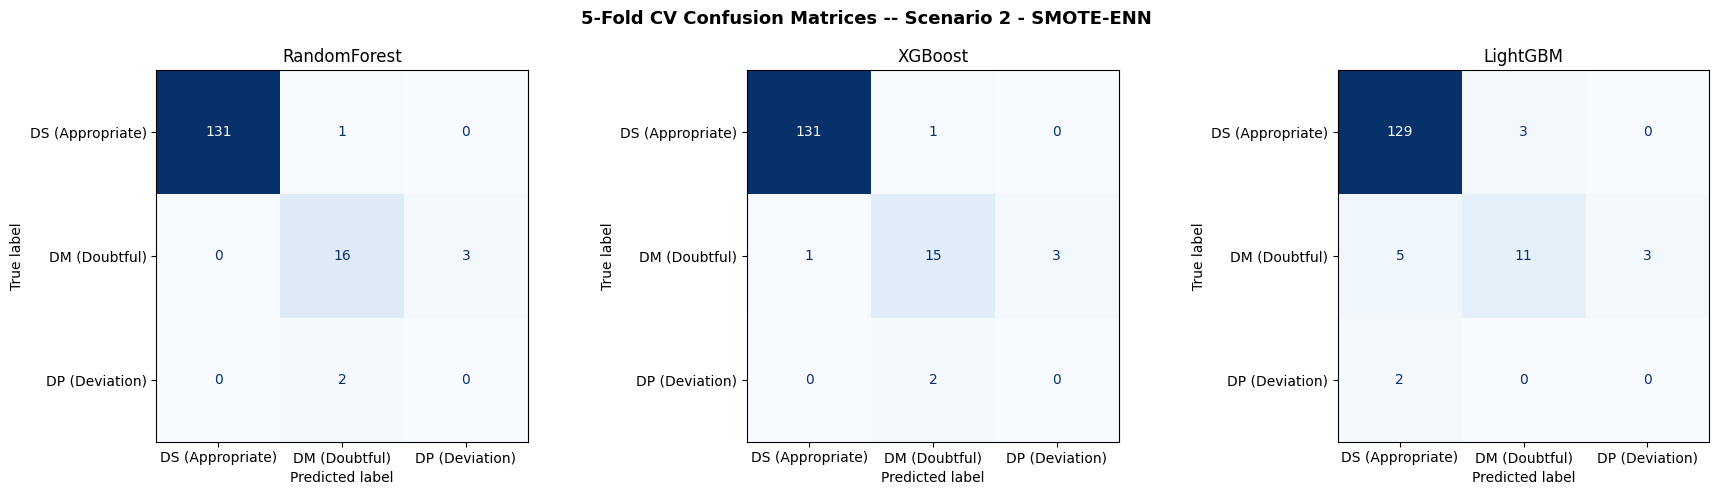

In [24]:
df_s2 = df.dropna(subset=['Target_Scenario_2']).copy()
X2 = df_s2[feature_cols]
y2 = df_s2['Target_Scenario_2'].astype(int)

min_class_count = y2.value_counts().min()
global skf
original_skf = skf

if min_class_count < skf.n_splits:
    print(f"\n[WARNING] Fallback: Least populated class has {min_class_count} members.")
    print(f"Using regular KFold(n_splits=5) instead of StratifiedKFold to prevent crash!\n")
    skf = KFold(n_splits=5, shuffle=True, random_state=42)

evaluate_cv(X2, y2, 'Baseline', 'Scenario 2 - Baseline')
evaluate_cv(X2, y2, 'OOSI', 'Scenario 2 - OOSI')
evaluate_cv(X2, y2, 'SMOTE-ENN', 'Scenario 2 - SMOTE-ENN')

skf = original_skf


In [25]:
X2_pre = preprocessor.fit_transform(X2)
X2_df = pd.DataFrame(X2_pre, columns=feature_names)
X_final_res, y_final_res = oosi(X2_df, y2, columns=feature_names)

xgb_explainer_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_explainer_model.fit(X_final_res, y_final_res)

print("Final Explainer Model Trained on OOSI (Scenario 2)")

Final Explainer Model Trained on OOSI (Scenario 2)



--- SHAP Bar Plot (Global Feature Importance across all classes) ---


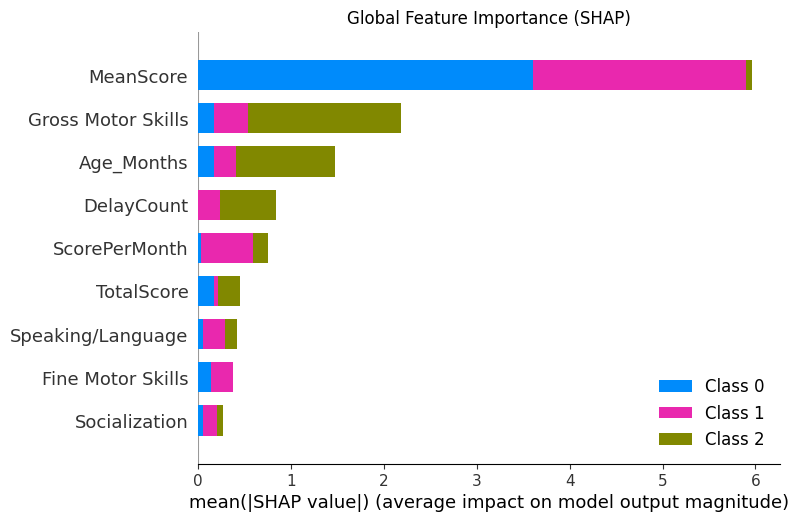


--- SHAP Summary Plot for Class 0 (DS) ---


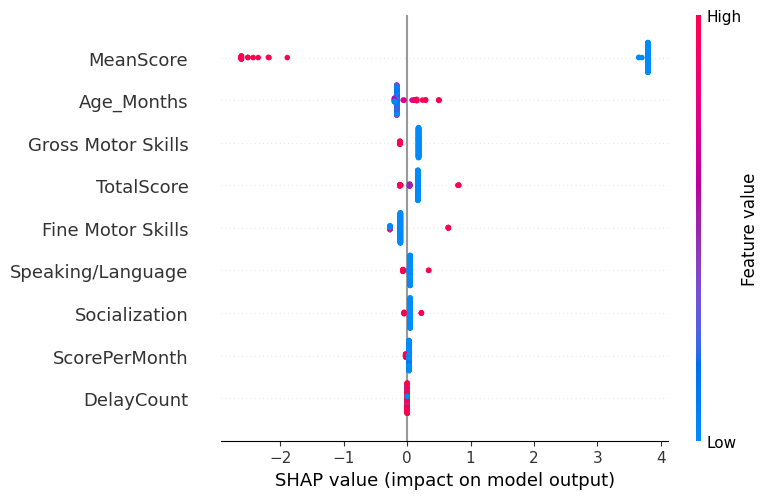

In [26]:
shap.initjs()

explainer = shap.TreeExplainer(xgb_explainer_model)
shap_values = explainer.shap_values(X2_df)

print("\n--- SHAP Bar Plot (Global Feature Importance across all classes) ---")
shap.summary_plot(shap_values, X2_df, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.show()

print("\n--- SHAP Summary Plot for Class 0 (DS) ---")
try:
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[0], X2_df, show=False)
    elif len(np.shape(shap_values)) == 3:
        shap.summary_plot(shap_values[:, :, 0], X2_df, show=False)
    else:
        shap.summary_plot(shap_values, X2_df, show=False)
    plt.show()
except Exception as e:
    print("Could not plot dot summary:", e)



--- LIME Local Explanation for Patient 0 ---
Actual Class: 1

(IPython display not available. Falling back to Matplotlib plot & text breakdown...)


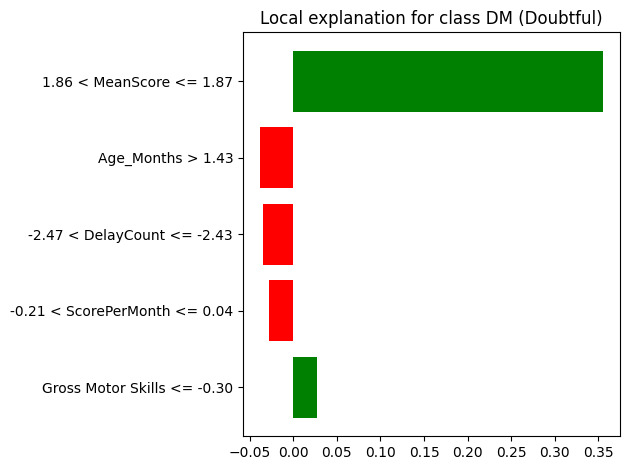


--- Top Influencing Factors ---
  1.86 < MeanScore <= 1.87: +0.3551
  Age_Months > 1.43: -0.0382
  -2.47 < DelayCount <= -2.43: -0.0353
  -0.21 < ScorePerMonth <= 0.04: -0.0274
  Gross Motor Skills <= -0.30: +0.0269


In [27]:
patient_idx = 0
patient_data = X2_df.iloc[patient_idx]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_final_res.values,
    feature_names=feature_names,
    class_names=['DS (Appropriate)', 'DM (Doubtful)', 'DP (Deviation)'],
    mode='classification',
    random_state=42
)

print(f"\n--- LIME Local Explanation for Patient {patient_idx} ---")
print(f"Actual Class: {y2.iloc[patient_idx]}")

exp = lime_explainer.explain_instance(
    data_row=patient_data.values,
    predict_fn=xgb_explainer_model.predict_proba,
    num_features=5,
    top_labels=1
)

try:
    exp.show_in_notebook(show_table=True)
except ImportError:

    print("\n(IPython display not available. Falling back to Matplotlib plot & text breakdown...)")
    fig = exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()
    
    print("\n--- Top Influencing Factors ---")
    for feature, weight in exp.as_list():
        print(f"  {feature}: {weight:+.4f}")



--- Scenario 2: SHAP Force Plot ---
Patient 0 | Actual Class: 1


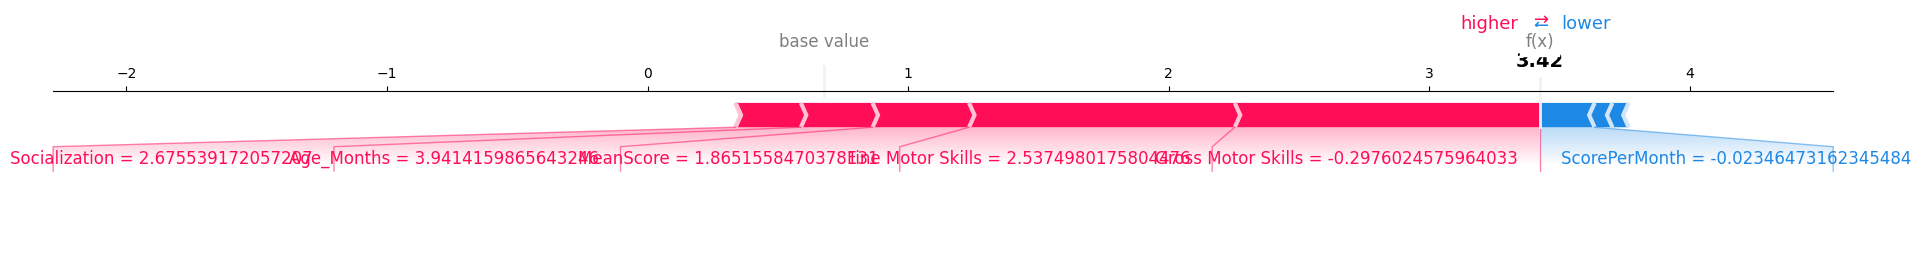

In [28]:
print("\n--- Scenario 2: SHAP Force Plot ---")
print(f"Patient {patient_idx} | Actual Class: {y2.iloc[patient_idx]}")

try:
    y2_pred_all   = xgb_explainer_model.predict(X2_df)
    class_to_plot = int(y2_pred_all[patient_idx])

    if isinstance(shap_values, list):
        sv = shap_values[class_to_plot][patient_idx, :]
        ev = explainer.expected_value[class_to_plot]
    elif len(np.shape(shap_values)) == 3:
        sv = shap_values[patient_idx, :, class_to_plot]
        ev = explainer.expected_value[class_to_plot]
    else:
        sv = shap_values[patient_idx, :]
        ev = explainer.expected_value

    shap.force_plot(ev, sv, X2_df.iloc[patient_idx, :], matplotlib=True, show=False)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not plot Force Plot: {e}")
